In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build the neural network
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # Convert 2D image to 1D
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits (0–9)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Save the model
model.save("digit_recognition_model.h5")


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9248 - loss: 0.2545 - val_accuracy: 0.9687 - val_loss: 0.1060
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9662 - loss: 0.1095 - val_accuracy: 0.9775 - val_loss: 0.0807
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9771 - loss: 0.0742 - val_accuracy: 0.9775 - val_loss: 0.0856
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0574 - val_accuracy: 0.9758 - val_loss: 0.0868
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0441 - val_accuracy: 0.9783 - val_loss: 0.0801
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0744


Test accuracy: 0.9786999821662903


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


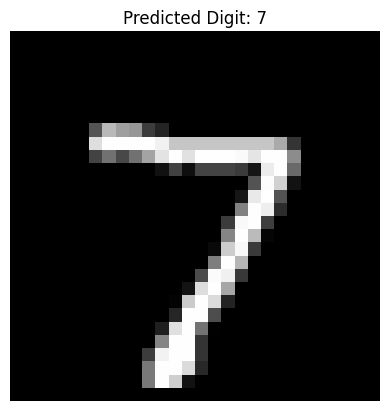

In [5]:
# Predict first test image
prediction = model.predict(x_test[:1])
predicted_digit = np.argmax(prediction)

plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()


In [6]:
predictions = model.predict(x_test[:5])
predicted_digits = np.argmax(predictions, axis=1)

print(predicted_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
[7 2 1 0 4]


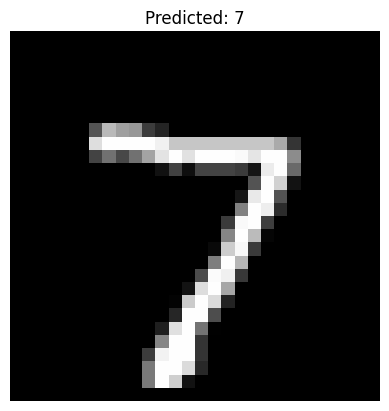

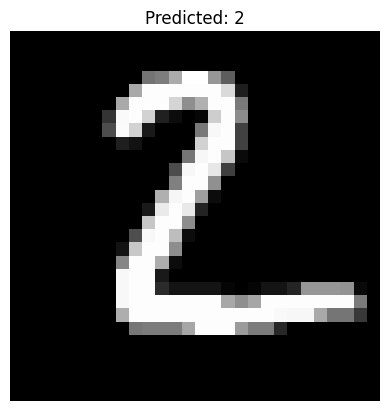

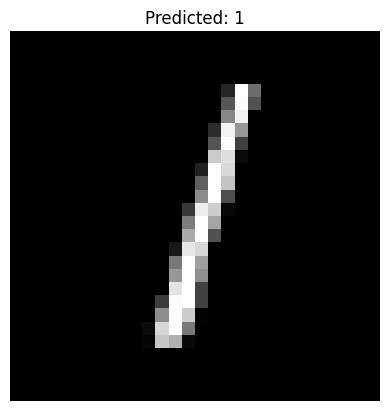

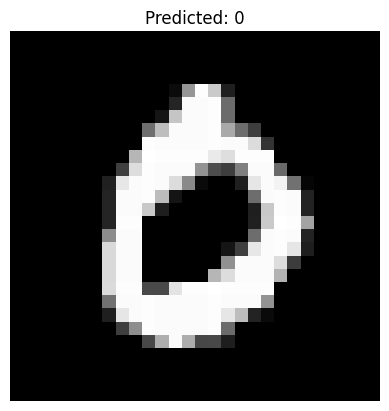

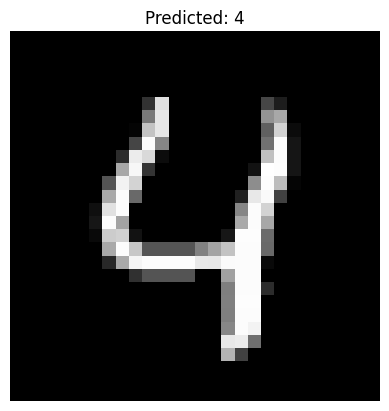

In [8]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_digits[i]}")
    plt.axis('off')
    plt.show()